# Business Problem Understanding

**Dream Housing Finance company deals in all kinds of home loans. They have presence across all urban, semi urban and rural areas. Customer first applies for home loan and after that company validates the customer eligibility for loan.**

**Company wants to automate the loan eligibility process (real time) based on customer detail provided while filling online application form. These details are Gender, Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History and others. To automate this process, they have provided a dataset to identify the customers segments that are eligible for loan amount so that they can specifically target these customers.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings ('ignore')

In [7]:
data = pd.read_csv('LoanData.csv')
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Data Understanding

Loan_ID: Unique Loan ID

Gender: Male/Female

Married: Applicant married

Dependents: Number of dependents

Education: Applicant Education

Self_Employed: whether the applicant is Self employed

ApplicantIncome: Applicant income

CoapplicantIncome: Coapplicant income

LoanAmount: Loan amount in thousands

Loan_Amount_Term: Term of loan in months

Credit_History: credit history meets guidelines

Property_Area: Urban/ Semi Urban/ Rural

Loan_Status: Loan approved **target variable**

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [9]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [10]:
data['Loan_ID'].nunique()

614

**Drop unimportant columns as per feature Selection (Filter Methods)**

In [11]:
data.drop(columns=["Loan_ID"], inplace=True)

In [12]:
data['Gender'].unique()

array(['Male', 'Female', nan], dtype=object)

In [13]:
data['Gender'].value_counts()

Gender
Male      489
Female    112
Name: count, dtype: int64

In [14]:
data['Married'].unique()

array(['No', 'Yes', nan], dtype=object)

In [15]:
data["Married"].value_counts()

Married
Yes    398
No     213
Name: count, dtype: int64

In [16]:
data['Dependents'].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [17]:
data['Dependents'].value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

In [18]:
data['Education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [19]:
data['Education'].value_counts()

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

In [20]:
data['Self_Employed'].unique()

array(['No', 'Yes', nan], dtype=object)

In [21]:
data['Self_Employed'].value_counts()

Self_Employed
No     500
Yes     82
Name: count, dtype: int64

**Create New Columns as per requirements**

In [22]:
data["Income"] = data['ApplicantIncome'] + data['CoapplicantIncome']  

data.drop(columns=['ApplicantIncome', 'CoapplicantIncome'], inplace=True)

In [23]:
data["Income"].describe()

count      614.000000
mean      7024.705081
std       6458.663872
min       1442.000000
25%       4166.000000
50%       5416.500000
75%       7521.750000
max      81000.000000
Name: Income, dtype: float64

In [24]:
data['Loan_Amount_Term'].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [25]:
data['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [26]:
data['Credit_History'].unique()

array([ 1.,  0., nan])

In [29]:
data['Credit_History'] = data['Credit_History'].replace({1:"good", 0:"bad"})

In [30]:
data['Credit_History'].unique()

array(['good', 'bad', nan], dtype=object)

In [31]:
data['Credit_History'].value_counts()

Credit_History
good    475
bad      89
Name: count, dtype: int64

In [32]:
data['Property_Area'].unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [33]:
data['Property_Area'].value_counts()

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

In [34]:
data['Loan_Status'].unique()

array(['Y', 'N'], dtype=object)

In [35]:
data['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [36]:
continous = ['Income', 'LoanAmount']
discrete_categorical = ['Gender', 'Married', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area','Loan_Status']
discrete_count = ['Dependents', 'Loan_Amount_Term']

In [37]:
data.dtypes

Gender               object
Married              object
Dependents           object
Education            object
Self_Employed        object
LoanAmount          float64
Loan_Amount_Term    float64
Credit_History       object
Property_Area        object
Loan_Status          object
Income              float64
dtype: object

# Exploratory Data Analysis (EDA)
**for continous Variables**

In [38]:
data[continous].describe()

,Income,LoanAmount
count,614.000000,592.000000
mean,7024.705081,146.412162
std,6458.663872,85.587325
min,1442.000000,9.000000
25%,4166.000000,100.000000
50%,5416.500000,128.000000
75%,7521.750000,168.000000
max,81000.000000,700.000000


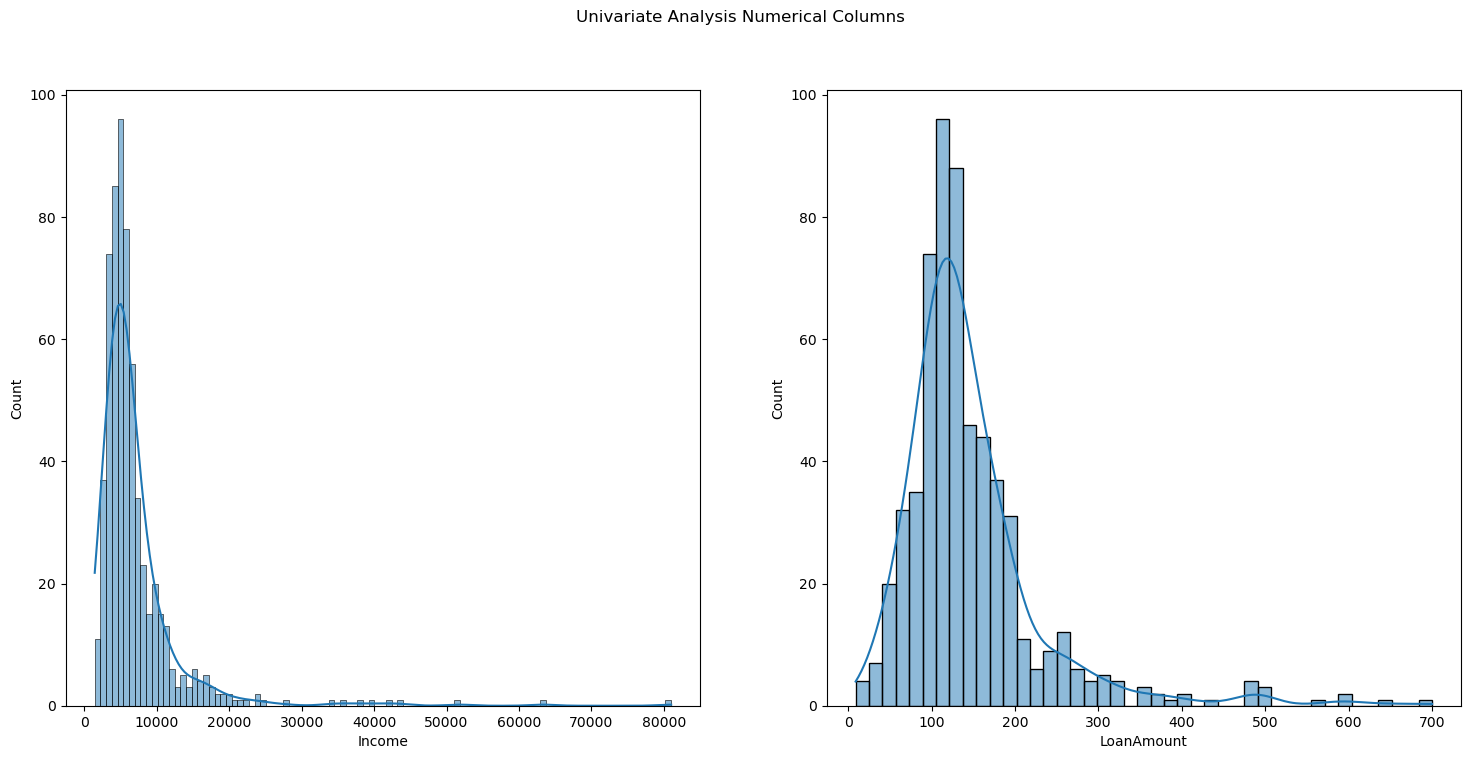

In [39]:
plt.rcParams['figure.figsize'] = (18,8)
plt.subplot(1,2, 1)
sns.histplot(data['Income'], kde=True)
plt.subplot(1,2, 2)
sns.histplot(data['LoanAmount'], kde=True)
plt.suptitle('Univariate Analysis Numerical Columns')
plt.show()

In [40]:
data [ continous].skew()

Income        5.633449
LoanAmount    2.677552
dtype: float64

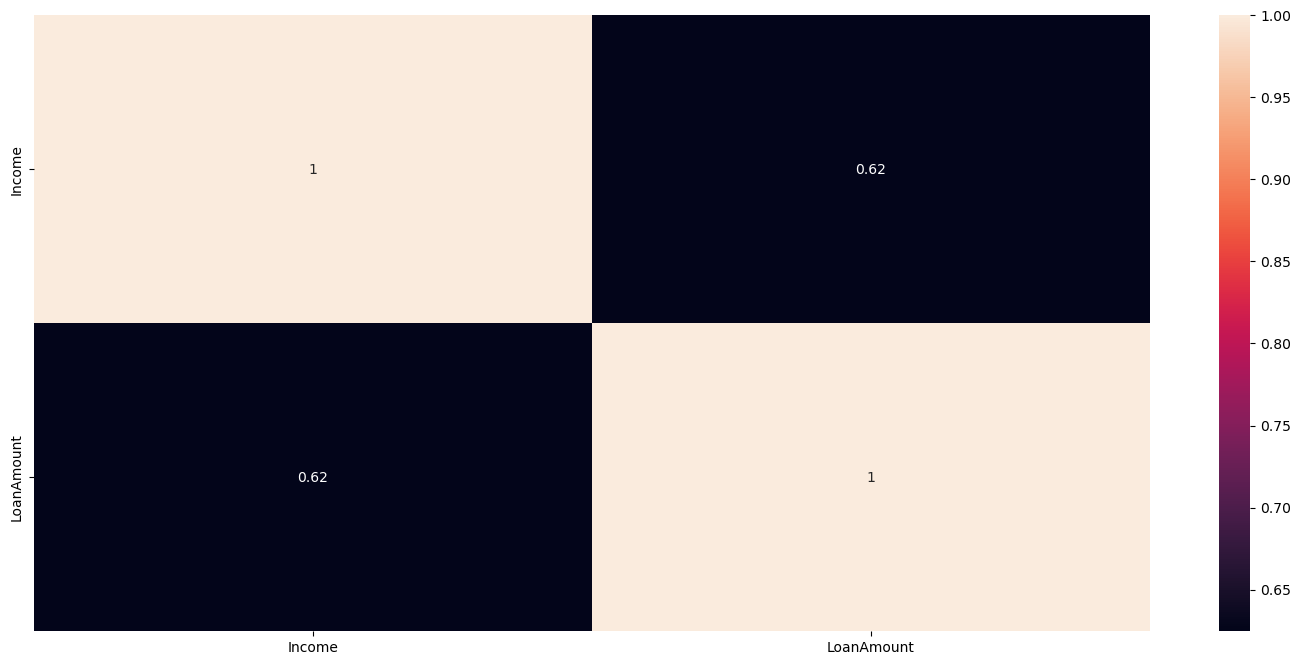

In [44]:
sns.heatmap(data [continous].corr(), annot=True)
plt.show()

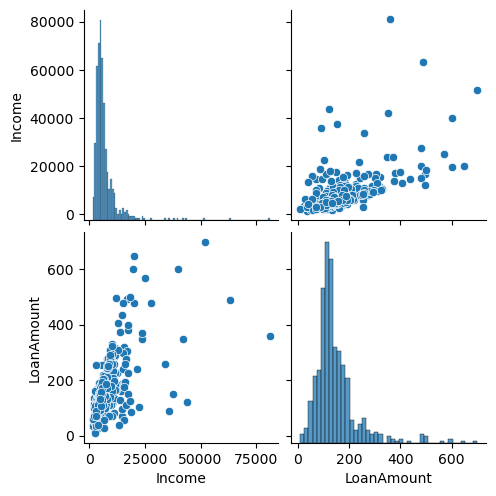

In [42]:
sns.pairplot(data[continous])
plt.show()

**for Discrete Variables**

In [45]:
data[discrete_categorical].describe()

,Gender,Married,Education,Self_Employed,Credit_History,Property_Area,Loan_Status
count,601,611,614,582,564,614,614
unique,2,2,2,2,2,3,2
top,Male,Yes,Graduate,No,good,Semiurban,Y
freq,489,398,480,500,475,233,422


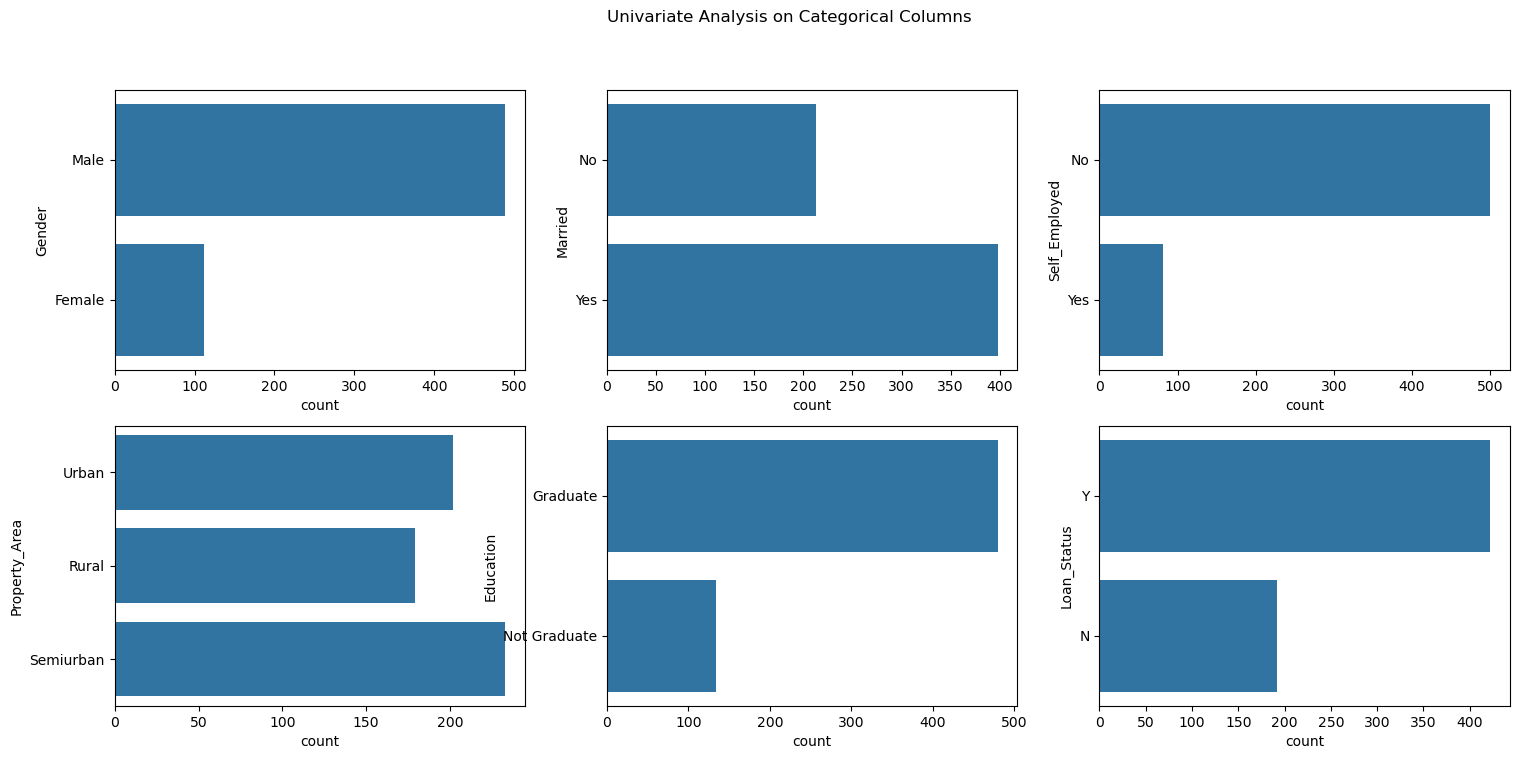

In [46]:
plt.rcParams['figure.figsize'] = (18,8)
plt.subplot(2, 3, 1)
sns.countplot(data['Gender'])
plt.subplot(2, 3, 2)
sns.countplot(data['Married'])
plt.subplot(2, 3, 3)
sns.countplot(data['Self_Employed'])
plt.subplot(2, 3, 4)
sns.countplot(data['Property_Area'])
plt.subplot(2, 3, 5)
sns.countplot(data['Education'])
plt.subplot(2, 3, 6)
sns.countplot(data['Loan_Status'])
plt.suptitle('Univariate Analysis on Categorical Columns')
plt.show()

In [47]:
1 # Lets compare all the Categories with respect to the Loan Status to understand the Overi

print("Impact of Marraige on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Married']))
print('\n')
print("Impact of Dependents on Loan Status")
print(pd.crosstab (data['Loan_Status'], data['Dependents']))
print('\n')
print("Impact of Education on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Education']))
print('\n')
print("Impact of Employment on Loan Status")
print(pd.crosstab (data['Loan_Status'], data['Self_Employed']))
print('\n')

# Lets compare all the Categories with respect to the Loan Sta
print("Impact of Marraige on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Married']))
print('\n')
print("Impact of Dependents on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Dependents']))
print('\n')
print("Impact of Education on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Education']))
print('\n')
print("Impact of Employment on Loan Status")
print(pd.crosstab (data['Loan_Status'], data['Self_Employed']))
print('\n')
print("Impact of Property on Loan Status")
print(pd.crosstab(data['Loan_Status'], data['Property_Area']))
print("\n")
print("Impact of Property on Loan Status")
print(pd.crosstab (data['Loan_Status'], data['Credit_History']))

Impact of Marraige on Loan Status
Married       No  Yes
Loan_Status          
N             79  113
Y            134  285


Impact of Dependents on Loan Status
Dependents     0   1   2  3+
Loan_Status                 
N            107  36  25  18
Y            238  66  76  33


Impact of Education on Loan Status
Education    Graduate  Not Graduate
Loan_Status                        
N                 140            52
Y                 340            82


Impact of Employment on Loan Status
Self_Employed   No  Yes
Loan_Status            
N              157   26
Y              343   56


Impact of Marraige on Loan Status
Married       No  Yes
Loan_Status          
N             79  113
Y            134  285


Impact of Dependents on Loan Status
Dependents     0   1   2  3+
Loan_Status                 
N            107  36  25  18
Y            238  66  76  33


Impact of Education on Loan Status
Education    Graduate  Not Graduate
Loan_Status                        
N                 140 

**Checking for Missing Values**

In [48]:
data.isnull().sum()

Gender              13
Married              3
Dependents          15
Education            0
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
Property_Area        0
Loan_Status          0
Income               0
dtype: int64

**check for Skewness**

In [49]:
data[continous].skew()

Income        5.633449
LoanAmount    2.677552
dtype: float64

**check outliers**

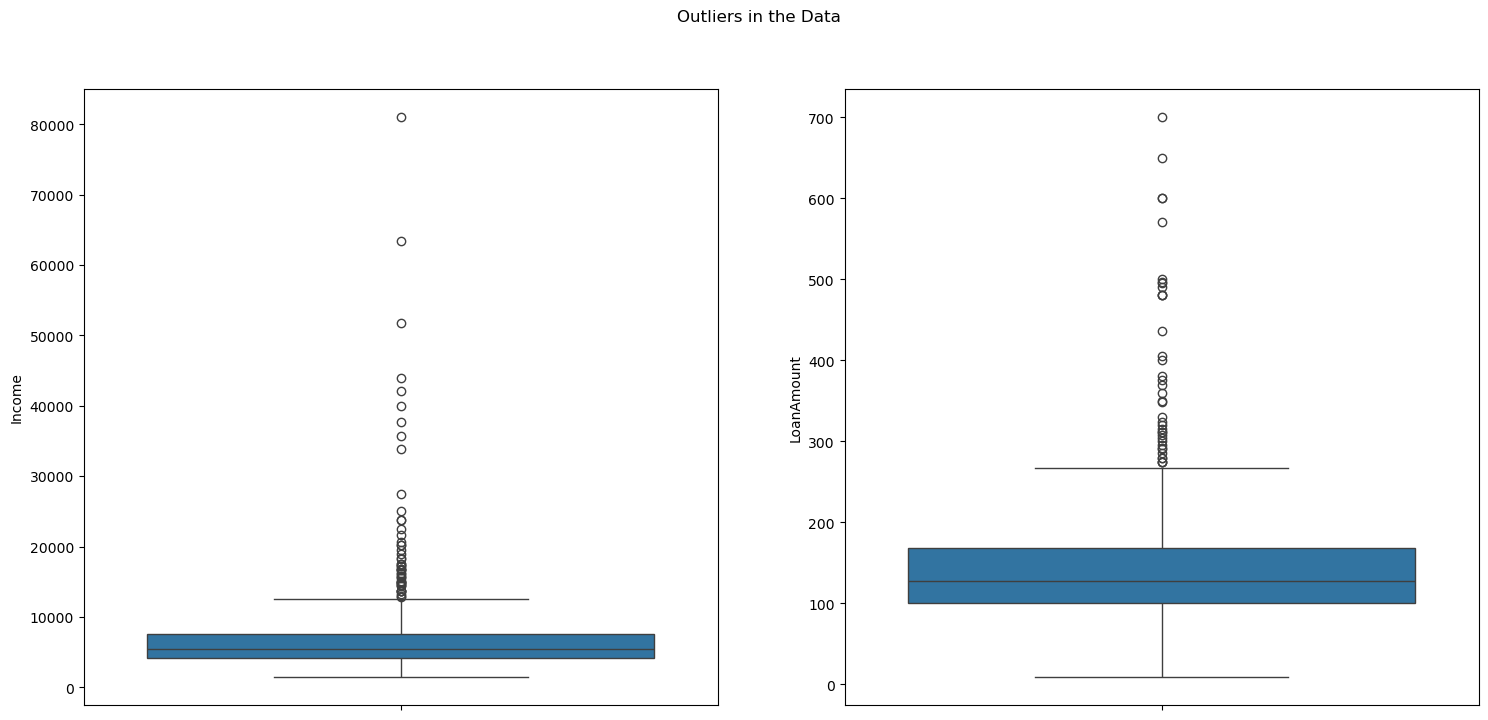

In [50]:
# Lets visualize the outliers using Box Plot
plt.subplot(1, 2, 1)
sns.boxplot(data['Income'])
plt.subplot(1, 2, 2)
sns.boxplot(data['LoanAmount'])
plt.suptitle('Outliers in the Data')
plt.show()

# Stage-3: Data Preparation

**1. Data Cleaning**

* Wrong data
* Missing values
* wrong data type
* duplicates
* outliers

**2. Data Wrangling**

* transformation (applicable on continous)
* scaling (applicable on continous)
* encoding (applicable on discrete categorical)
* **Dont apply any Data Wrangling technique on Count Variable**


**Wrong Data treatment**

In [51]:
data['Dependents'] = data['Dependents'].replace({'3+':3})

**Missing Values Treatment**

In [52]:
data['Dependents'] = data['Dependents'].fillna(0)
data['Gender'] = data['Gender'].fillna (data['Gender'].mode()[0])
data['Married'] = data['Married'].fillna (data['Married'].mode()[0])
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])
data= data.dropna(subset=["Income", 'LoanAmount', 'Loan_Amount_Term', 'Credit_History'])

**data type conversion**

In [53]:
data['Dependents'] = data['Dependents'].astype('int')
data['Loan_Amount_Term']=data['Loan_Amount_Term'].astype('int')

**outliers treatment**

In [ ]:
# outliers should be retrained (because really some people will have high income)

**Encoding**

In [54]:
data['Gender'] = data['Gender'].replace({'Male':1, 'Female':0})
data['Married'] = data['Married'].replace({'Yes': 1, 'No':0})
data['Education'] = data['Education'].replace({'Graduate': 1, 'Not Graduate':0})
data['Self_Employed'] = data['Self_Employed'].replace({'Yes': 1, 'No':0})
data['Property_Area'] = data['Property_Area'].replace({'Rural' : 0, 'Semiurban': 1, 'Urban':2})
data['Credit_History'] = data['Credit_History'].replace({'good': 1, 'bad' : 0})
data['Loan_Status'] = data['Loan_Status'].replace({'Y':1, 'N':0})

**transformations**

In [56]:
from scipy.stats import boxcox
data['Income'], a = boxcox(data['Income'])
data['LoanAmount'], c = boxcox(data['LoanAmount'])

In [57]:
data['Loan_Amount_Term'] = data['Loan_Amount_Term']/12

**X&y**

In [58]:
X = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

**train-test split**

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size = 0.2, random_state = 7)

In [61]:
!pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/72.0 MB 4.1 MB/s eta 0:00:18
    --------------------------------------- 1.6/72.0 MB 3.7 MB/s eta 0:00:20
   - -------------------------------------- 2.1/72.0 MB 3.4 MB/s eta 0:00:21
   - -------------------------------------- 2.9/72.0 MB 3.6 MB/s eta 0:00:20
   -- ------------------------------------- 3.7/72.0 MB 3.5 MB/s eta 0:00:20
   -- ------------------------------------- 4.7/72.0 MB 3.6 MB/s eta 0:00:19
   --- ------------------------------------ 5.5/72.0 MB 3.7 MB/s eta 0:00:18
   --- ------------------------------------ 6.3/72.0 MB 3.7 MB/s eta 0:00:18
   --- ------------------------------------ 7.1/72.0 MB 3.7 MB/s eta 0:00:18
   ---- ----------------------------------- 7.9/72.0 MB 3.7 MB/s eta 0:00:18
   ---- ----------------------------------- 8.7/72.0 MB 3.7 MB/s eta 0:00:18
   ----- ---------------------------------- 9.4/72.0 MB 3.7 MB/s eta 0:00:18
   ---

# Stage -4: Modelling & Evaluation

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

# 1.Logistic Regression

In [63]:
#Modelling

from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train,y_train)
#Predict & Evaluate on train data
ypred_train = log_model.predict(X_train)
# default thresold value is 0.5
print("Train Accuracy: ", accuracy_score(y_train, ypred_train))
#Cross Validation on Train data
print("CV Score:", cross_val_score(log_model, X_train, y_train, cv=5, scoring="accuracy").mean())
#predict & Evaluation on test data
ypred_test = log_model.predict(X_test)
print("Test Accuracy :", accuracy_score(y_test, ypred_test))

Train Accuracy:  0.8085106382978723
CV Score: 0.8060504201680672
Test Accuracy : 0.839622641509434


In [64]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,ypred_test))
from sklearn.metrics import classification_report
print(classification_report(y_test, ypred_test))

[[ 5 28]
 [10 63]]
              precision    recall  f1-score   support

           0       0.33      0.15      0.21        33
           1       0.69      0.86      0.77        73

    accuracy                           0.64       106
   macro avg       0.51      0.51      0.49       106
weighted avg       0.58      0.64      0.59       106



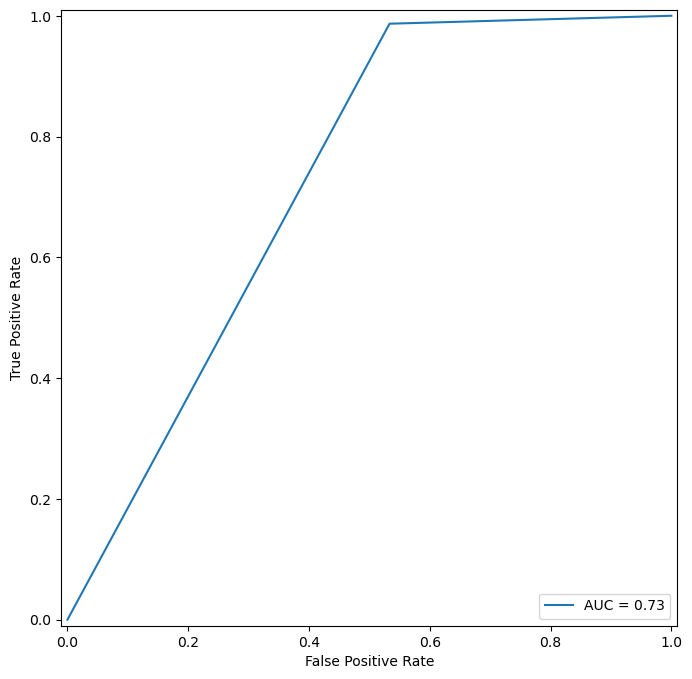

In [65]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
fpr, tpr, thresholds = roc_curve(y_test,ypred_test)
roc_auc = auc (fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
plt.show()

In [66]:
#AUC Score
from sklearn.metrics import roc_auc_score
print("AUC Score:", roc_auc_score(y_test, ypred_test))

AUC Score: 0.7267543859649123


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# ------------------------------
# 1. Separate target
# ------------------------------
X = data.drop(columns=['Loan_Status'])
y = data['Loan_Status']

# ------------------------------
# 2. Columns list
# ------------------------------
continuous_cols = ['Income', 'LoanAmount']
categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']
numeric_count_cols = ['Dependents', 'Loan_Amount_Term']

# ------------------------------
# 3. Preprocessing
# ------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', PowerTransformer(method='box-cox', standardize=True), continuous_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num2', 'passthrough', numeric_count_cols)
    ]
)

# ------------------------------
# 4. Build Pipeline
# ------------------------------
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# ------------------------------
# 5. Train-test split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# 6. Train Model
# ------------------------------
model.fit(X_train, y_train)

# ------------------------------
# 7. Evaluate
# ------------------------------
y_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))









new_applicant = pd.DataFrame({
    'Gender': [1],              # Male
    'Married': [1],             # Yes
    'Dependents': [1],          
    'Education': [1],           # Graduate
    'Self_Employed': [0],       # No
    'Income': [6000],
    'LoanAmount': [150],
    'Loan_Amount_Term': [360],
    'Credit_History': [1],      # good
    'Property_Area': [2]        # Urban
})


print(model.predict(new_applicant))
print(model.predict_proba(new_applicant))



Test Accuracy: 0.8301886792452831
              precision    recall  f1-score   support

           0       0.94      0.48      0.64        33
           1       0.81      0.99      0.89        73

    accuracy                           0.83       106
   macro avg       0.88      0.74      0.76       106
weighted avg       0.85      0.83      0.81       106

[1]
[[0. 1.]]


# 2. KNN

* HPT
* Modelling & Evaluation

In [67]:
# Hyperparameter tuning

estimator = KNeighborsClassifier()
param_grid = {'n_neighbors': list(range(1,50)),"p":[1,2]}
knn_grid = GridSearchCV(estimator, param_grid, scoring='accuracy', cv=5)
knn_grid.fit(X_train,y_train)
#KNN with best Hyperparameters
knn_grid.best_estimator_

KNeighborsClassifier(n_neighbors=12, p=1)

In [68]:
#Modelling
knn_model = knn_grid.best_estimator_
knn_model.fit(X_train,y_train)
#Predict & Evaluate on train data
ypred_train = knn_model.predict(X_train)
print("Train Accuracy: ", accuracy_score (y_train, ypred_train))
#Cross Validation on Train data
print("CV Score:", cross_val_score(knn_model, X_train, y_train, cv=5, scoring="accuracy").mean())
#Predict & Evaluate on test data
ypred_test = knn_model.predict(X_test)
print("Test Accuracy:", accuracy_score (y_test, ypred_test))

Train Accuracy:  0.806146572104019
CV Score: 0.7445658263305323
Test Accuracy: 0.7264150943396226


# 3.Support Vector Machine (SVM)
* HPT
* Modelling & Evaluation

In [69]:
#Hyperparameter tuning
from sklearn.svm import SVC
estimator = SVC()
param_grid = {'C': [0.01,0.1,1], 'kernel': ['linear', 'rbf', 'sigmoid', 'poly']}
svm_grid = GridSearchCV(estimator, param_grid, scoring='accuracy', cv=5)
svm_grid.fit(X_train,y_train)
#SVM with best Hyperparameters
svm_grid.best_estimator_

SVC(C=0.1, kernel='linear')

In [70]:
#Modelling

svm_model = svm_grid.best_estimator_
svm_model.fit(X_train,y_train)
#Predict & Evaluate on train data
ypred_train = svm_model.predict(X_train)
print("Train Accuracy: ", accuracy_score(y_train, ypred_train))
#Cross Validation on Train data
print("CV Score:", cross_val_score(svm_model, X_train,y_train,cv=5, scoring="accuracy").mean())
#Predict & Evaluate on test data
ypred_test = svm_model.predict(X_test)
print("Test Accuracy: ", accuracy_score (y_test, ypred_test))

Train Accuracy:  0.8085106382978723
CV Score: 0.8084313725490195
Test Accuracy:  0.839622641509434


# 4.Decision Tree Classifier
* HPT
* Identify important features by using feature seclection (ensemble method)
* Modelling & Evaluation
  
**first create default DT model (fully grown tree without any pruning) so that, we can understand the max_depth**

In [71]:
model = DecisionTreeClassifier(random_state=True)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=True)

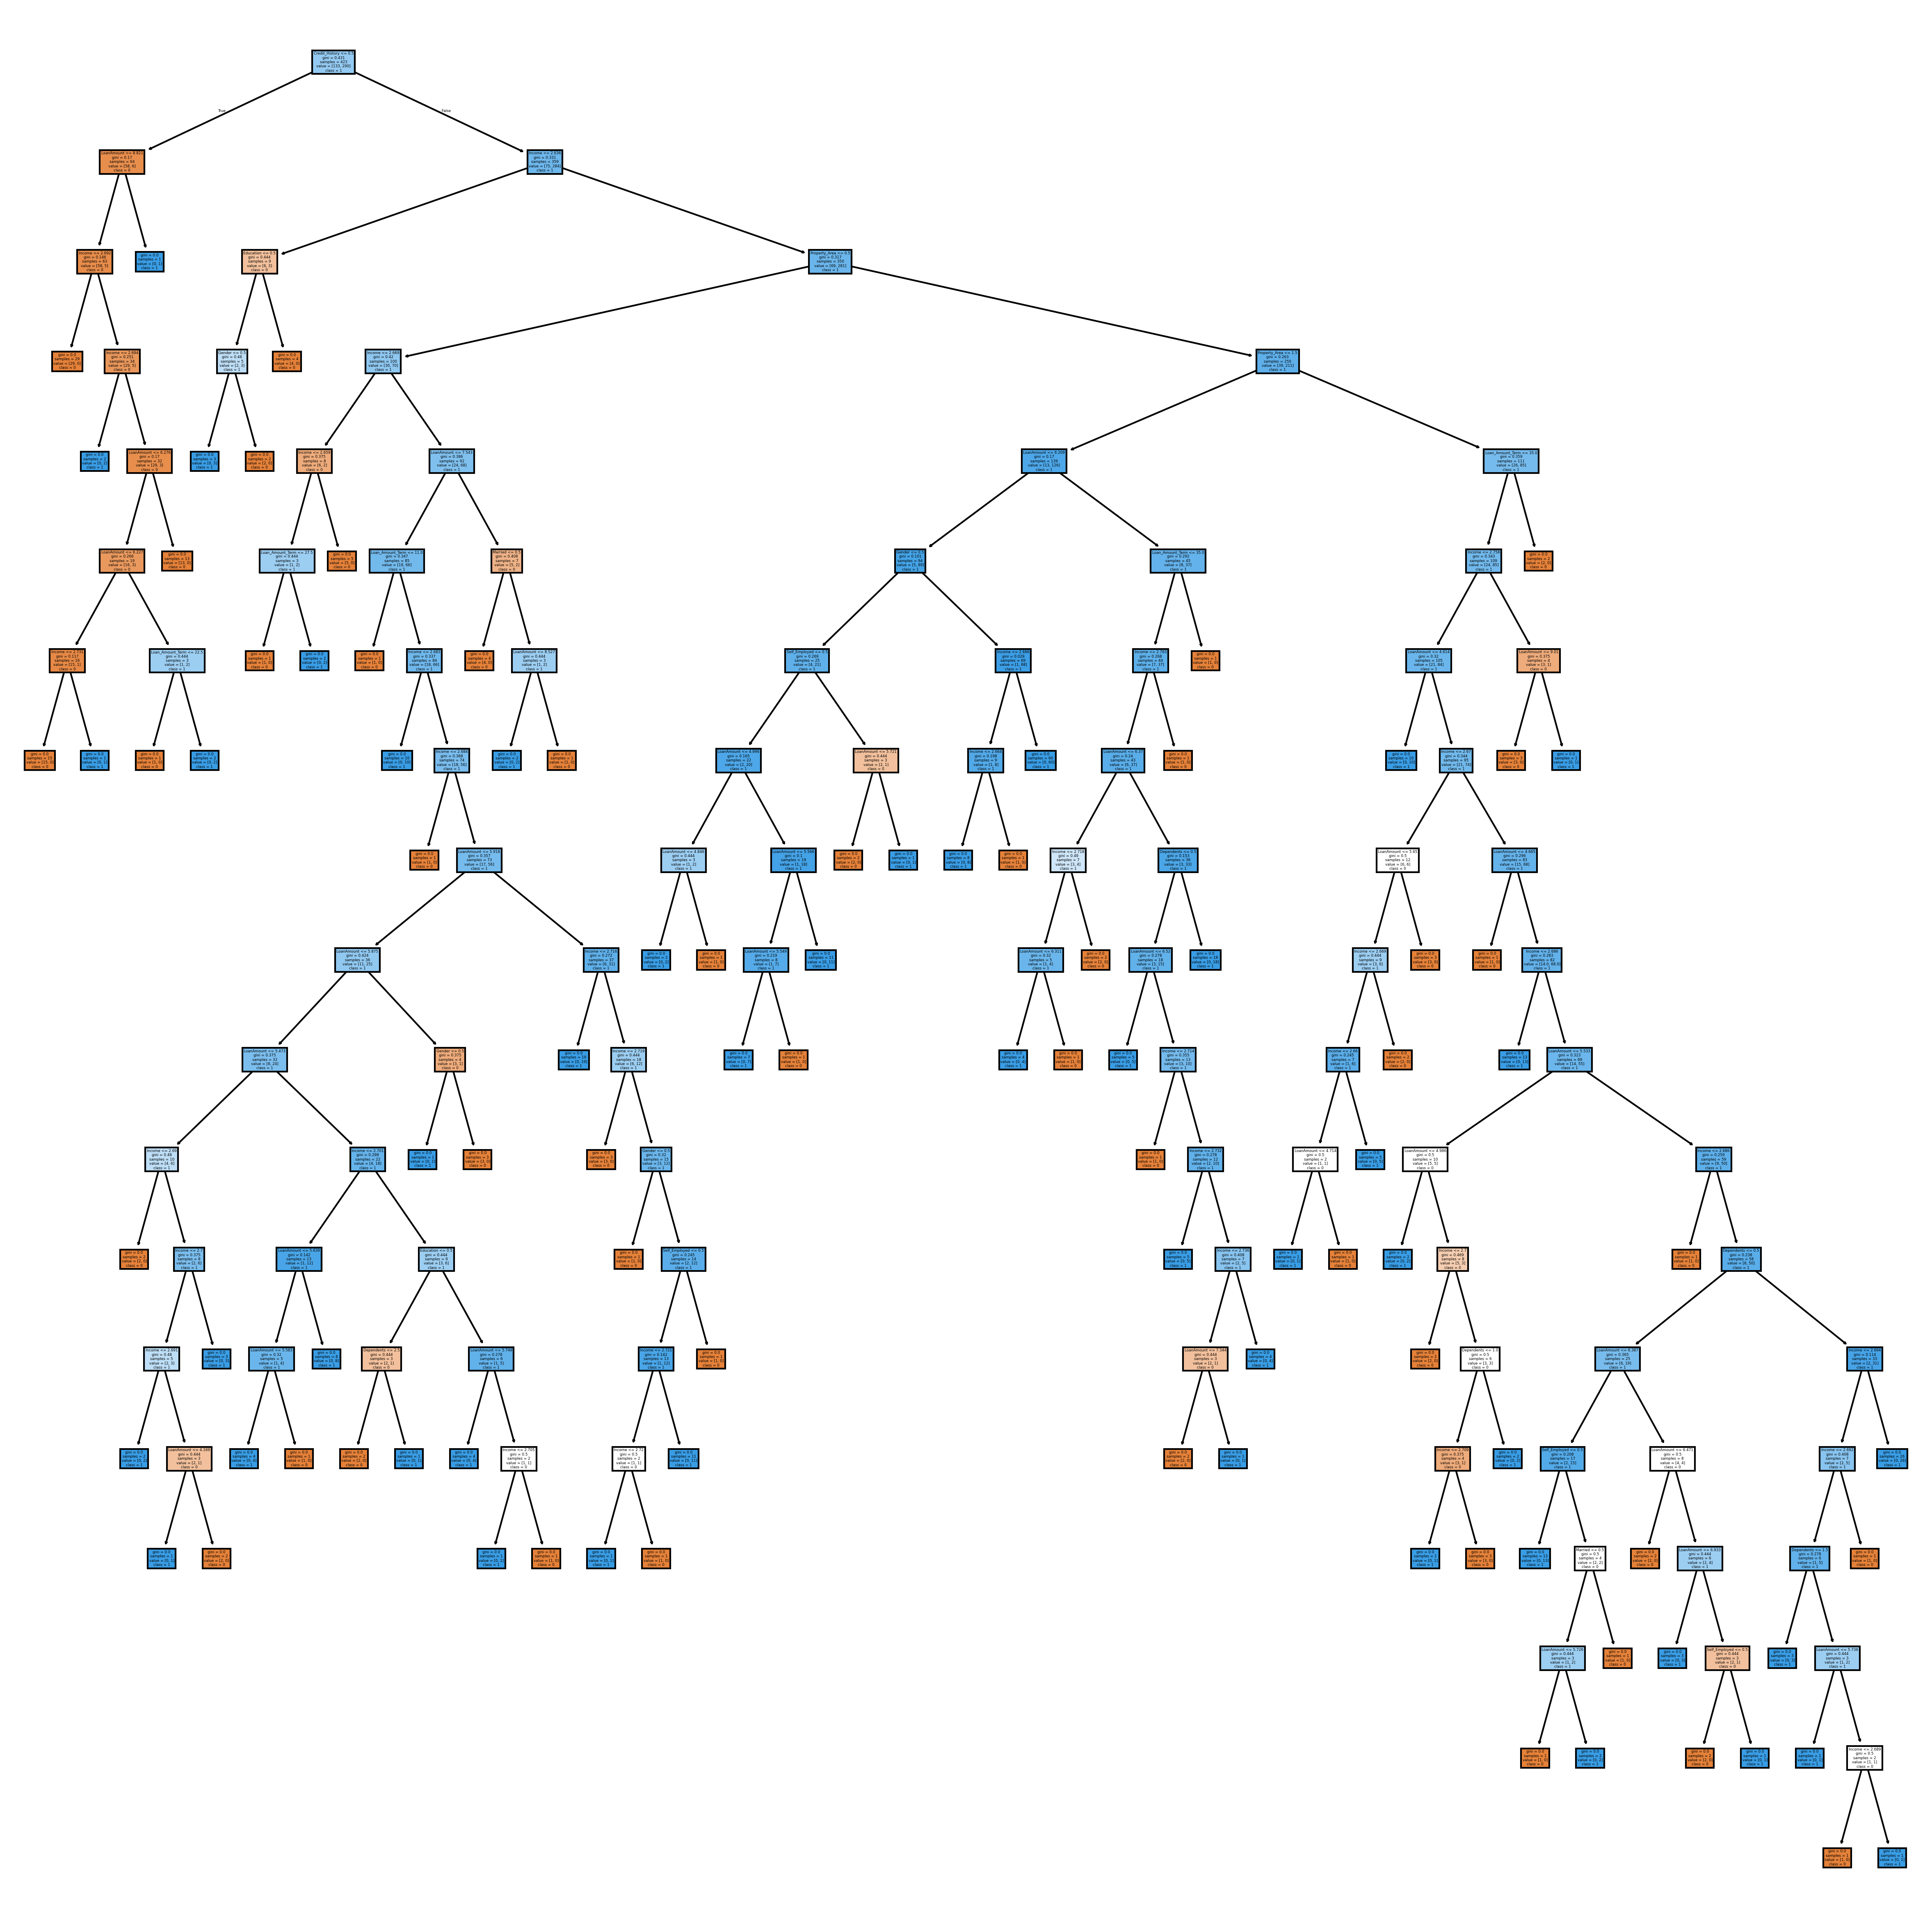

In [72]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,20),dpi=300)
plot_tree (model, filled=True,feature_names=X_train.columns.tolist(),class_names=["0","1"])
plt.show()

In [73]:
#Hyper parameter tuning

estimator = DecisionTreeClassifier (random_state=True)
param_grid = {"criterion": ["gini", "entropy"],"max_depth": list(range(1,16))}
dt_grid = GridSearchCV(estimator, param_grid, scoring='accuracy',cv=5)
dt_grid.fit(X_train,y_train)
dt = dt_grid.best_estimator_
dt

DecisionTreeClassifier(max_depth=1, random_state=True)

In [74]:
#Important features
feats_ab = pd.DataFrame(data=dt.feature_importances_,index=X.columns,columns=['Importance'])
important_features_dt = feats_ab[feats_ab["Importance"]>0].index.tolist()
important_features_dt

['Credit_History']

**Creating Decison Tree Model with important parameters and important features**

In [75]:
#Selecting train & test data
X_train_dt = X_train [important_features_dt]
X_test_dt = X_test[important_features_dt]
#Modelling
dt = dt_grid.best_estimator_
dt.fit(X_train_dt,y_train)
#Evaluation
ypred_train = dt.predict(X_train_dt)
ypred_test = dt.predict(X_test_dt)
print("Train Accuracy:", accuracy_score(y_train, ypred_train))
print("CV Score:", cross_val_score(dt, X_train_dt, y_train, cv=5, scoring="accuracy").mean())
print("Test Accuracy:", accuracy_score(y_test, ypred_test))

Train Accuracy: 0.8085106382978723
CV Score: 0.8084313725490195
Test Accuracy: 0.839622641509434


# 5.Random Forest Classifier

* HPT
* identify important features
* Modelling
* Evaluation

In [ ]:
#Hyper parameter tuning

estimator = RandomForestClassifier(random_state=True)
param_grid = {'n_estimators': list(range(1,51))}
rf_grid = GridSearchCV(estimator, param_grid, scoring="accuracy", cv=5)
rf_grid.fit(X_train,y_train)
rf= rf_grid.best_estimator_
rf

In [ ]:
#Important features
feats_ab = pd.DataFrame(data=rf.feature_importances_,
index=X.columns,
columns=['Importance'])
important_features_rf = feats_ab[feats_ab["Importance"]>0].index.tolist()

In [ ]:
X_train_rf = X_train [important_features_rf]
X_test_rf = X_test [important_features_rf]
#Modelling
rf= rf_grid.best_estimator_
rf.fit(X_train_rf,y_train)
#Evaluation
ypred_train = rf.predict(X_train_rf)
ypred_test = rf.predict(X_test_rf)
print("Train Accuracy:", accuracy_score(y_train, ypred_train))
print("CV score:", cross_val_score(rf, X_train_rf, y_train, cv=5,scoring="accuracy").mean())
print("Test Accuracy :", accuracy_score(y_test, ypred_test))

# 6.AdaBoost Classifier

In [ ]:
estimator = AdaBoostClassifier(random_state=True)
param_grid = {'n_estimators': list(range(1,51))}
ab_grid=GridSearchCV(estimator, param_grid, scoring="accuracy", cv=5)
ab_grid.fit(X_train,y_train)
ab = ab_grid.best_estimator_
ab

In [ ]:
#Important features

feats_ab = pd. DataFrame(data=ab.feature_importances_,
index=X.columns,
columns=['Importance'])
important_features_ab = feats_ab[feats_ab["Importance"]>0].index.tolist()
important_features_ab

In [ ]:
X_train_ab = X_train [important_features_ab]
X_test_ab = X_test [important_features_ab]
#Modelling
ab =ab_grid.best_estimator_
ab.fit(X_train_ab,y_train)
#Evaluation
ypred_train =ab.predict(X_train_ab)
ypred_test = ab.predict(X_test_ab)
print("Train Accuracy :", accuracy_score(y_train, ypred_train))
print("CV Score:", cross_val_score(ab,X_train_ab,y_train, cv=5, scoring="accuracy").mean())
print("Test Accuracy:", accuracy_score(y_test, ypred_test))

# 7. Gradient Boost Classifier

In [ ]:
estimator = GradientBoostingClassifier (random_state=True)
param_grid = {"n_estimators": list(range(1,10)),"learning_rate" : [0.1,0.2,0.3,0.4,0.5,0.7,0.8,0.9,1.0]}
gb_grid = GridSearchCV(estimator, param_grid, scoring="accuracy", cv=5)
gb_grid.fit(X_train,y_train)
gb = gb_grid.best_estimator_
gb

In [ ]:
#Important features

feats_gb= pd.DataFrame(data=gb.feature_importances_,index=X.columns,columns=['Importance'])
important_features_gb = feats_gb [feats_gb["Importance"]>0].index.tolist()
important_features_gb

In [ ]:
X_train_gb = X_train [important_features_gb]
X_test_gb = X_test [important_features_gb]
gb= gb_grid.best_estimator_
gb.fit(X_train_gb,y_train)
ypred_train = gb.predict(X_train_gb)
ypred_test = gb.predict(X_test_gb)
print("Train Accuracy: ", accuracy_score(y_train, ypred_train))
print("CV Score:", cross_val_score(gb, X_train_gb,y_train, cv=5, scoring="accuracy").mean())
print("Test Accuracy :", accuracy_score(y_test, ypred_test))

# 8. XGBoost Classifier

In [ ]:
#Hyperparameter tuning

estimator = XGBClassifier()
param_grid = {"n_estimators": [10,20,40,100],'max_depth': [3,4,5],'gamma': [0,0.15,0.3,0.5,1]}
xgb_grid = GridSearchCV(estimator, param_grid, scoring="accuracy", cv=5)
xgb_grid.fit(X_train,y_train)
xgb = xgb_grid.best_estimator_
xgb

In [ ]:
#Important features

feats_xgb = pd.DataFrame(data=xgb.feature_importances_,index=X.columns,columns=['Importance'])
important_features_xgb = feats_xgb[feats_xgb["Importance"]>0].index.tolist()
important_features_xgb

In [ ]:
X_train_xgb = X_train [important_features_xgb]
X_test_xgb = X_test [important_features_xgb]
#Modelling
xgb = xgb_grid.best_estimator_
xgb.fit(X_train_xgb,y_train)
#Evaluation
ypred_train= xgb.predict(X_train_xgb)
ypred_test = xgb.predict(X_test_xgb)
print("Train Accuracy: ", accuracy_score(y_train, ypred_train))
print("CV Score:", cross_val_score(xgb, X_train_xgb,y_train, cv=5, scoring="accuracy").mean())
print("Test Accuracy: ", accuracy_score(y_test, ypred_test))

# Save the best Model

In [ ]:
from joblib import dump
dump(dt, 'loan.joblib')

# Predict on New data

In [ ]:
input_data = {"Loan_ID": "LP002991","Gender": "Male","Married":"No","Dependents":1,"Education":"Graduate","Self_Employed":"yes","ApplicantIncome":1000,"CoapplicantIncome":0,"LoanAmount":100,"Loan_Amount_Term":240,"Credit_History":"bad","Property_Area": "Urban"}

In [ ]:
data =pd.DataFrame(input_data, index=[0])
data

**Apply Data preprocessing on Unknown Data**

In [ ]:
data.drop(columns=["Loan_ID"], inplace=True)
data["Income"] = data['ApplicantIncome'] + data['CoapplicantIncome']
data.drop(columns=['ApplicantIncome', 'CoapplicantIncome'], inplace=True)
data['Dependents'] = data['Dependents'].fillna(0)
data['Gender'] = data['Gender'].fillna (data['Gender'].mode()[0])
data['Married'] = data['Married'].fillna (data['Married'].mode() [0])
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])
data = data.dropna(subset=["Income", 'LoanAmount', 'Loan_Amount_Term', 'Credit_History'])
data['Dependents'] = data['Dependents'].astype('int')
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].astype('int')
data['Gender'] = data['Gender'].replace({'Male': 1, 'Female':0})
data['Married'] = data['Married'].replace({'Yes': 1, 'No' : 0})
data['Education'] = data['Education'].replace({'Graduate': 1, 'Not Graduate':0})
data['Self_Employed'] = data['Self_Employed'].replace({'yes': 1, 'No':0})
data['Property_Area'] = data['Property_Area'].replace({'Rural' : 0, 'Semiurban': 1, 'Urban':2})
data['Credit_History'] = data['Credit_History'].replace({'good':1, 'bad' : 0})
data['Loan_Amount_Term'] = data['Loan_Amount_Term']/12
X_new = data

In [ ]:
# Select Important features of your best model
X_new = X_new[important_features_dt]
# Apply & Predict using your best model
dt.predict(X_new)